## > EDA : Exploratory Data Analysis and Visualization
**File:** `cleaned_listings.csv`

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white")
plt.rcParams["figure.figsize"]=(10,5)
df = pd.read_csv('../data/processed/cleaned_listings.csv')
print(f"Loaded {len(df)} records for EDA")

Loaded 12359 records for EDA


## 1.0 Price Distribution

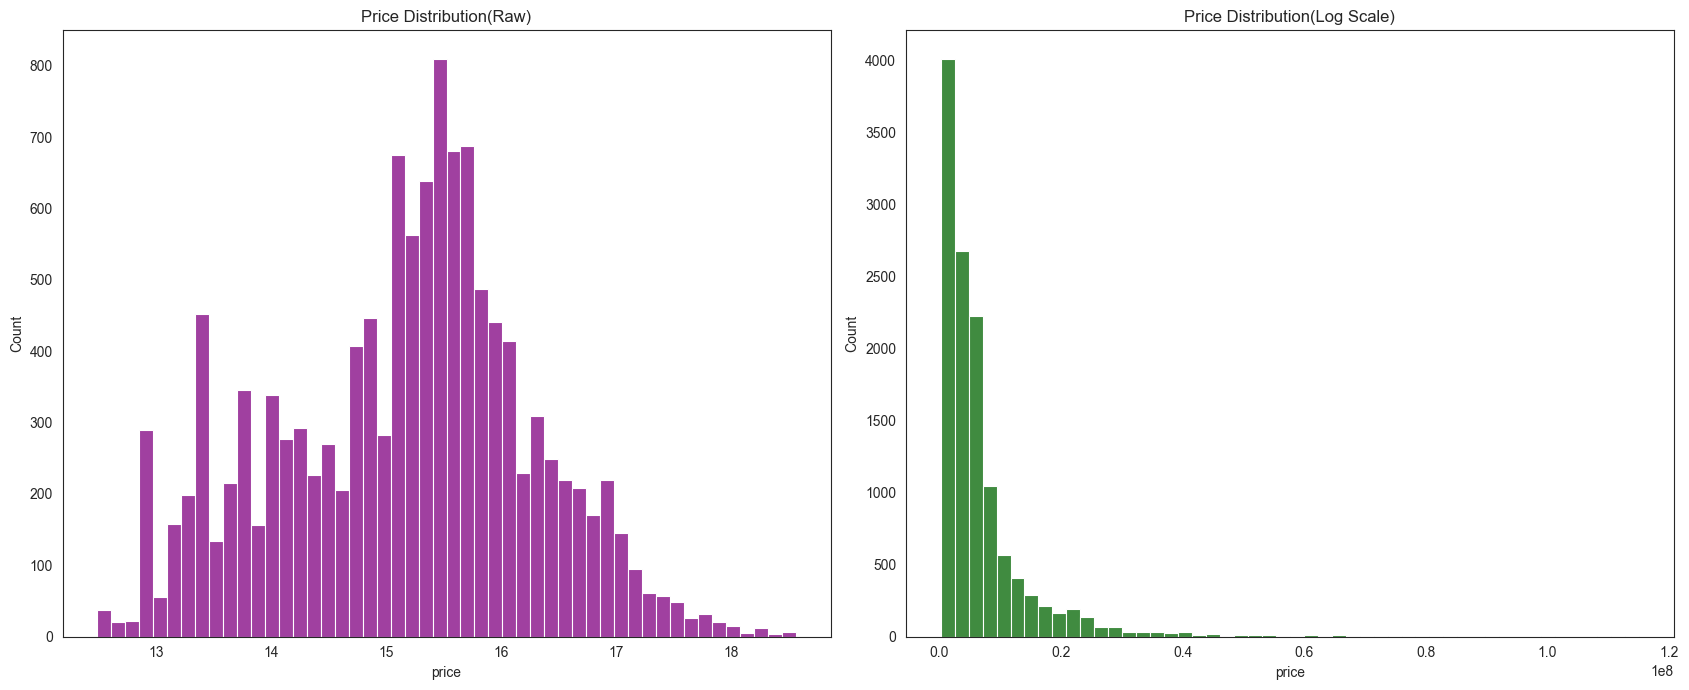

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.histplot(np.log1p(df["price"]), bins=50, ax=axes[0], color="purple")
axes[1].set_title("Price Distribution(Log Scale)")
sns.histplot(df["price"], bins=50, ax=axes[1], color="darkgreen")
axes[0].set_title("Price Distribution(Raw)")
plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.1 Price by location

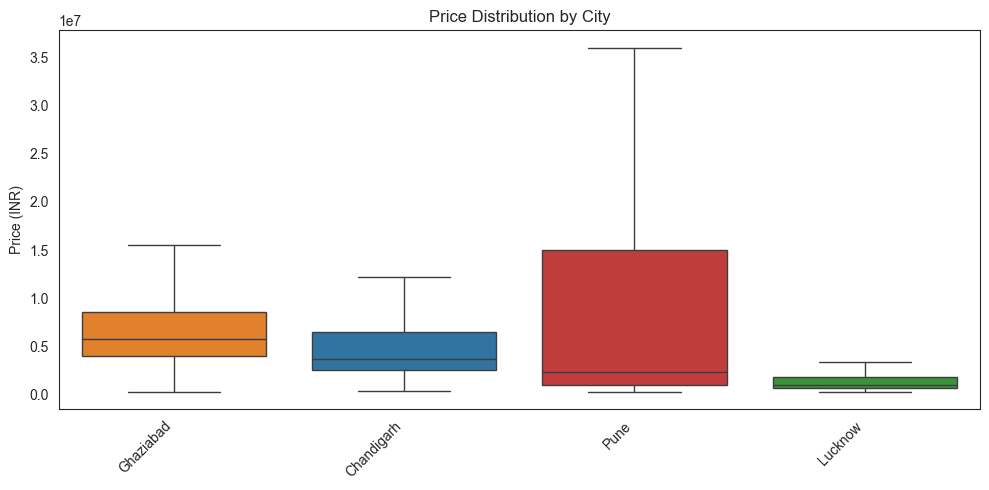

In [14]:
order = df.groupby("city")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, x="city", y="price",
    order=order,
    hue="city",
    palette="tab10",
    showfliers=False,
    legend=False
)
plt.title("Price Distribution by City")
plt.ylabel("Price (INR)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig('../reports/figures/price_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.2 Price by property type

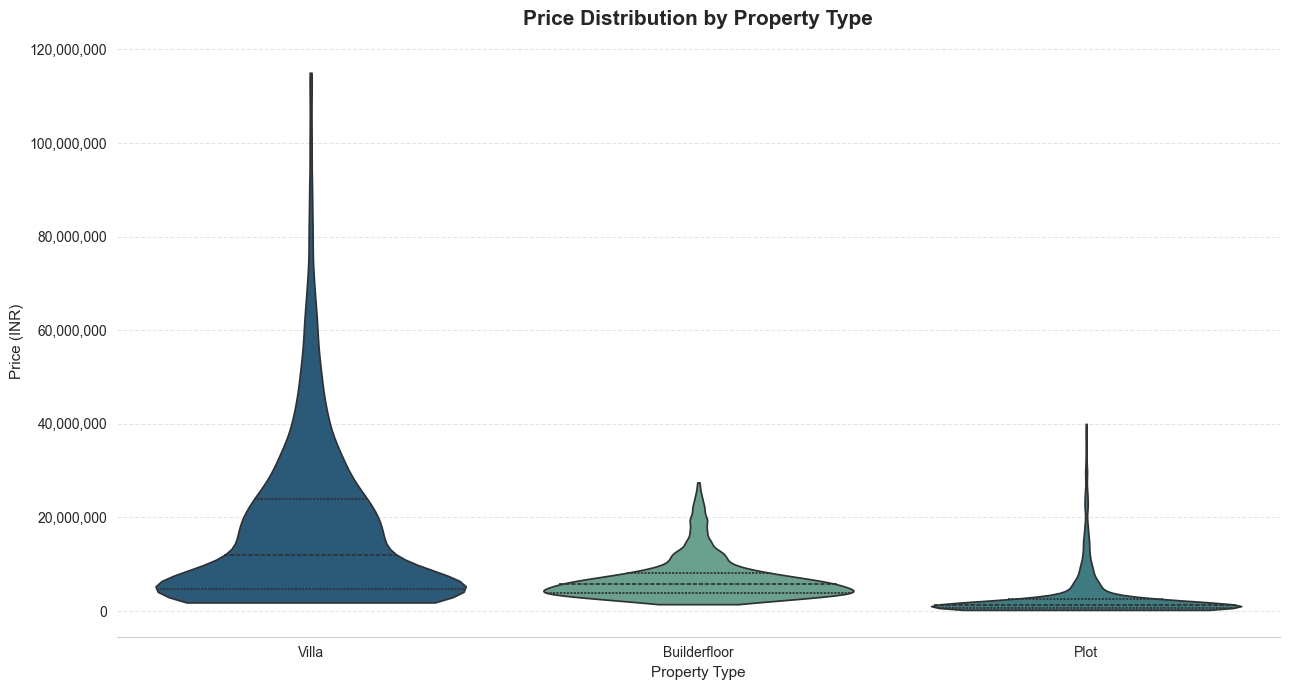

In [15]:
plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")  

order = df.groupby("property_type")["price"].median().sort_values(ascending=False).index

ax = sns.violinplot(
    data=df, x="property_type", y="price",
    order=order,
    hue="property_type",
    palette="crest",
    legend=False,
    inner="quartile",
    cut=0
)

ax.set_title("Price Distribution by Property Type", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Property Type", fontsize=11)
ax.set_ylabel("Price (INR)", fontsize=11)
sns.despine(left=True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
ax.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/price_by_property_type.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Price per SqFt - City x Property type

In [16]:
df["price_per_sqft"] = df["price"] / df["area"]
pivot = df.pivot_table(values="price_per_sqft", index="city", columns="property_type", aggfunc="median")
pivot

property_type,Builderfloor,Plot,Villa
city,,,
Chandigarh,3009.708738,2833.333333,4593.253968
Ghaziabad,4827.586207,2444.444444,3888.888889
Lucknow,3954.545455,700.000000,4160.000000
Pune,5327.217125,1000.000000,7801.553206


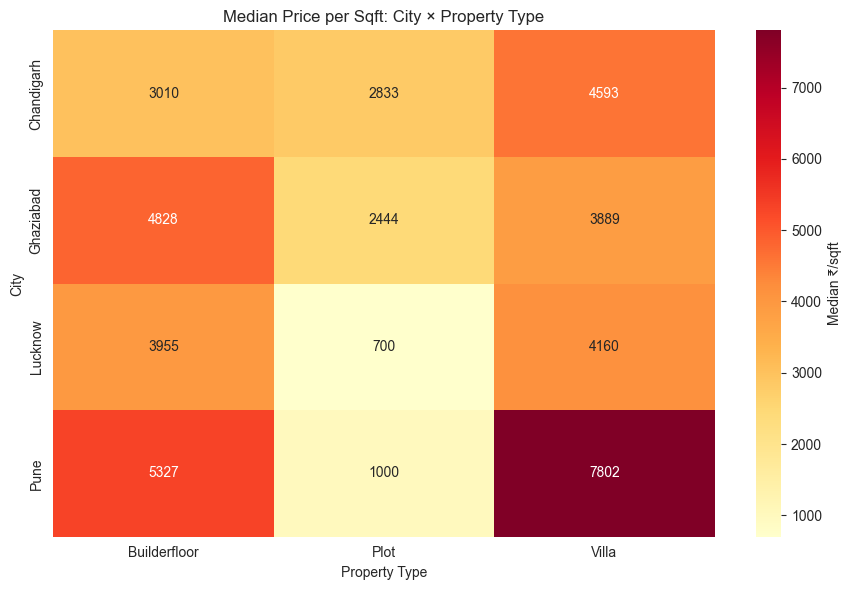

In [17]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "Median ₹/sqft"}
)
plt.title("Median Price per Sqft: City × Property Type")
plt.xlabel("Property Type")
plt.ylabel("City")
plt.tight_layout()

plt.savefig('../reports/figures/price_per_sqft.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.4 Price distiribution by New vs Resale

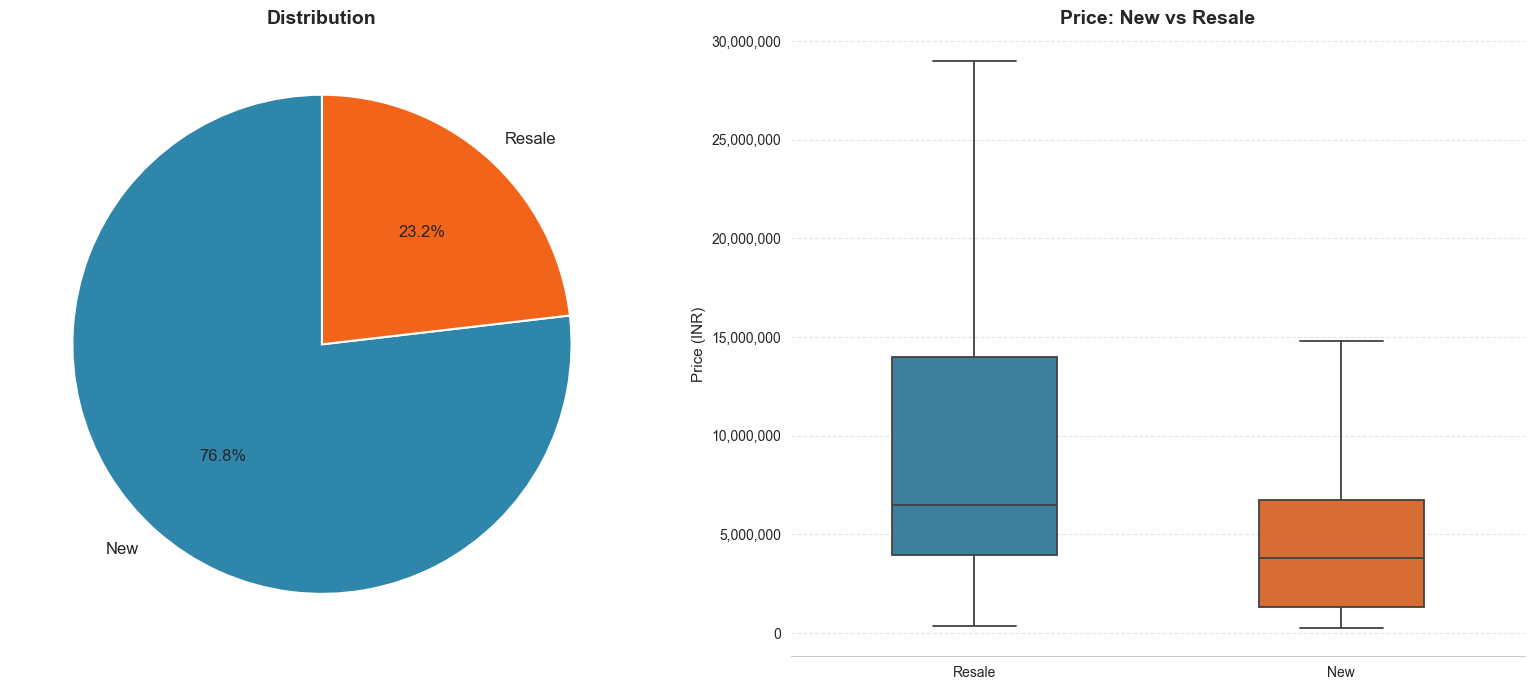

In [18]:

df["new/resale_label"] = df["new/resale"].map({0: "Resale", 1: "New"})  
order = df.groupby("new/resale_label")["price"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Pie chart
counts = df["new/resale_label"].value_counts()
colors = {"New": "#2E86AB", "Resale": "#F26419"}
plot_colors = [colors.get(cat, "#999999") for cat in counts.index]

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=plot_colors, startangle=90,
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
            textprops={'fontsize': 12})
axes[0].set_title("Distribution", fontsize=14, fontweight="bold")
# Boxplot
sns.boxplot(
    data=df, x="new/resale_label", y="price", order=order,
    showfliers=False, hue="new/resale_label",
    palette=["#2E86AB", "#F26419"], legend=False,
    width=0.45, linewidth=1.3, ax=axes[1]
)
axes[1].set_title("Price: New vs Resale", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (INR)", fontsize=11)
sns.despine(ax=axes[1], left=True)
axes[1].yaxis.grid(True, linestyle="--", alpha=0.5)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/figures/new_vs_resale.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.5 Amenities Count vs Price Distribution


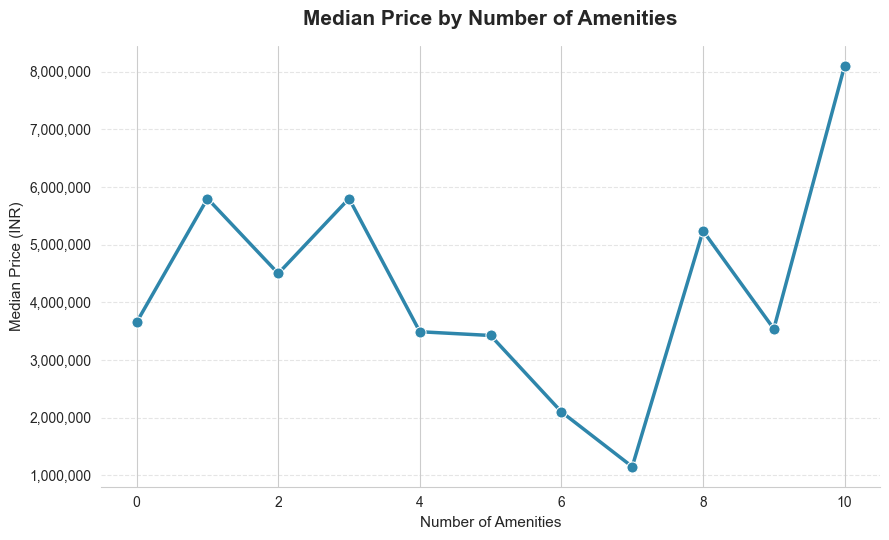

In [19]:
plt.figure(figsize=(9, 5.5))
sns.set_style("whitegrid")

summary = df.groupby("amenity_count")["price"].median().reset_index()

ax = sns.lineplot(
    data=summary, x="amenity_count", y="price",
    marker="o", color="#2E86AB", linewidth=2.5, markersize=8
)

ax.set_title("Median Price by Number of Amenities", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Amenities", fontsize=11)
ax.set_ylabel("Median Price (INR)", fontsize=11)
sns.despine(left=True)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/figures/amenities_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.6 Heatmap (Numeric Features)


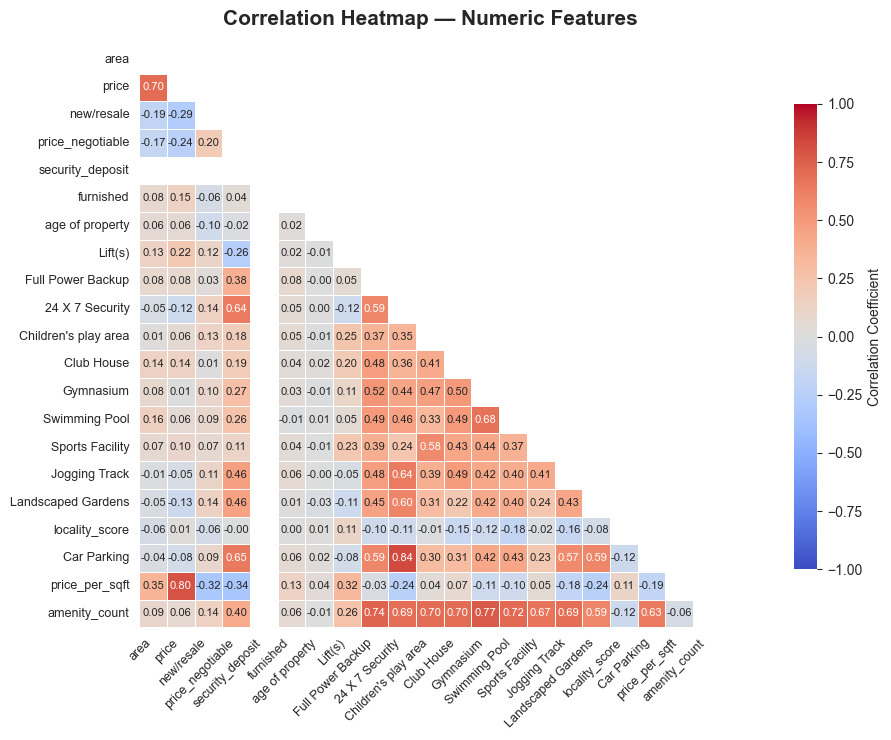

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(15, 7.5))
sns.set_style("white")

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation Coefficient", "shrink": 0.8},
    square=True,
    vmin=-1, vmax=1
)

ax.set_title("Correlation Heatmap — Numeric Features", fontsize=15, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/heatmap(numeric features).png', dpi=300, bbox_inches='tight')
plt.show()

## >Key Takeaways from the given graphs

1. Price Distribution
   > Log-transforming price stabilizes variance and outlier influence, aligns the data with linear modeling assumptions, and turns multiplicative price relationships into interpretable, percentage-based coefficients — leading to more accurate and fair predictions across all price ranges.
2. Price by Location
   > Pune shows both the widest price range and the highest whisker (~340M), while all four cities have tightly compressed, heavily right-skewed boxes near zero — indicating a small number of extreme high-priced properties even after excluding outliers.
3. Price by Property Type
   >Villas command the highest and most spread-out prices (median ~1.2Cr, range up to 5.5Cr), while builder floors and plots are progressively cheaper and more tightly clustered.
4. Price per SqFt - City x Property Type
   >Pune has the highest per-sqft prices across the board — especially for villas (₹7,838/sqft) — while plots are consistently the cheapest property type in every city, with Lucknow's plot rate (₹700/sqft) standing out as the overall low.
5. Price Distribution by New vs Resale
   >Properties labeled "No" (likely non-resale/new) have a higher median price (~₹65L) and wider spread than "Yes" (~₹40L), suggesting resale properties tend to be cheaper and more tightly priced.
6. Amenities Count vs Price Distribution
   >Median price shows no strong linear trend with amenity count, but properties with 8+ amenities show much wider price ranges and higher upper bounds, suggesting amenity count matters more for premium-property variance than for typical price level.
7. Heatmap (Numeric Features)
   >Price is most strongly correlated with price_per_sqft (0.68), moderately with area (0.23) and locality_score (0.18), while age of property shows almost no relationship with price (0.06).


**File:** `real_estate_user_cleaned.csv`

This notebook looks at prospective plot buyers/leads — their demographics, budget, and
behavior — to understand what's related to whether someone actually purchased a plot.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)


In [2]:
users = pd.read_csv('../data/processed/real_estate_user_cleaned.csv')
print("Shape:", users.shape)
users.head()

Shape: (12000, 27)


,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,Preferred_Plot_Size_SqFt,Preferred_Location,Distance_to_City_Center_km,Purpose,Loan_Required,Expected_Purchase_Timeline,Lead_Source,Enquiry_Date,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value,Outlier_Flag
0,CUST_20988,21,Male,IT & Software,Mumbai,131500.0,1578000.0,2,Owned Flat/House,7.020000e+06,1500.0,Suburbs,33.800000,Self-use,0,1-3 years,Google & Social Media Ads,2024-07-19,0,0,0,0,0.0639,Low,0,0.0,Inlier
1,CUST_16662,29,Male,Real Estate & Construction,Kolkata,43800.0,525600.0,4,Owned Flat/House,2.000000e+06,600.0,Within City Limits,17.000000,Self-use,1,1-3 years,Magicbricks / Real Estate Portal,2025-01-13,1,1,0,0,0.0668,Low,0,0.0,Inlier
2,CUST_10543,50,Male,Retail & Commerce,Noida,179000.0,2148000.0,2,Owned Flat/House,5.710000e+06,1200.0,Suburbs,20.300000,Investment,1,0-6 months,Channel Partner / Broker,2024-10-25,0,1,1,1,0.9900,High,1,5550000.0,Inlier
3,CUST_15741,44,Male,Retail & Commerce,Pune,45700.0,548400.0,4,Living with Parents,2.300000e+06,1000.0,Periphery / Growth Corridor,40.900000,Self-use,1,6-12 months,Print / Newspaper Ad,2025-06-06,1,1,0,0,0.2293,Low,0,0.0,Inlier
4,CUST_16911,38,Male,Self-Employed / Business,Ahmedabad,219400.0,2632800.0,4,Rented,1.635451e+07,1500.0,Suburbs,23.534197,Self-use,1,0-6 months,Magicbricks / Real Estate Portal,2024-09-30,0,1,0,1,0.7678,High,1,8930000.0,Inlier


## 2.0 Purchased — class balance (pie chart)

Purchased
0    7110
1    4890
Name: count, dtype: int64


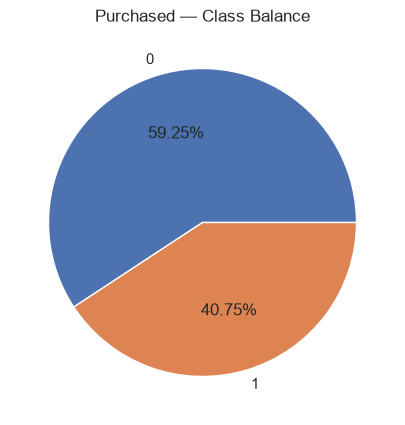

In [4]:
purchase_counts = users['Purchased'].value_counts()
print(purchase_counts)

plt.figure(figsize=(5, 5))
plt.pie(purchase_counts, labels=purchase_counts.index, autopct='%1.2f%%')
plt.title('Purchased — Class Balance')
plt.savefig('../reports/figures/class_balance.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.1 Demographics: Age, Gender, Family size

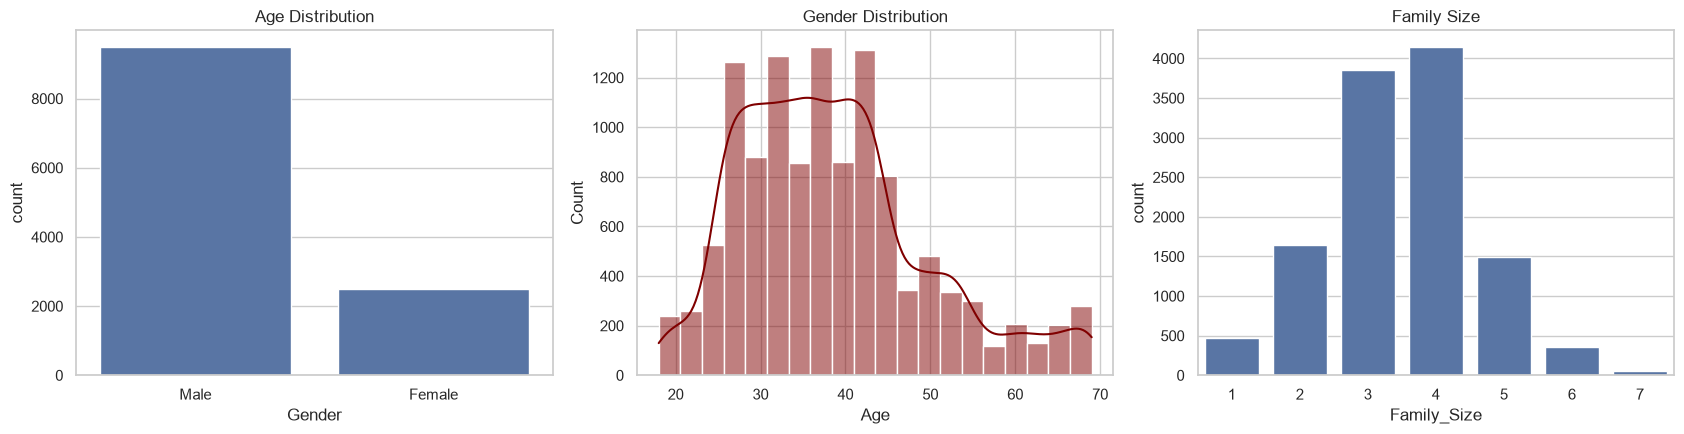

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Gender', ax=axes[0])
axes[1].set_title('Gender Distribution')

sns.histplot(users['Age'], bins=20, kde=True,color="maroon", ax=axes[1])
axes[0].set_title('Age Distribution')

sns.countplot(data=users, x='Family_Size', ax=axes[2])
axes[2].set_title('Family Size')
plt.savefig('../reports/figures/demographic_AGF.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 2.2 Income: Monthly vs Annual

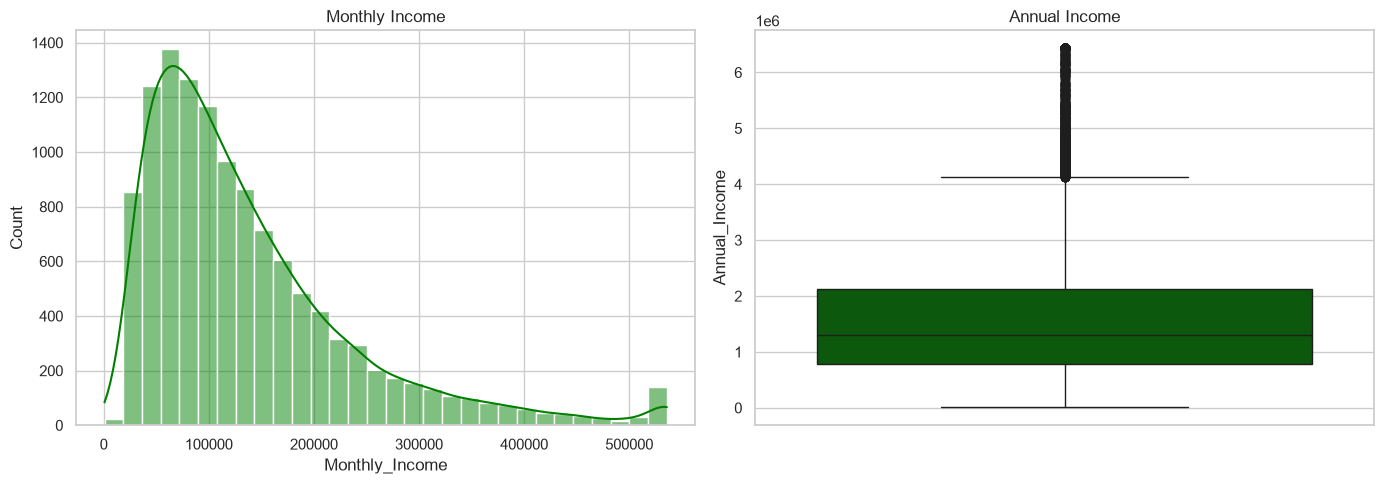

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Monthly_Income'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Monthly Income')

sns.boxplot(y=users['Annual_Income'], ax=axes[1], color='darkgreen')
axes[1].set_title('Annual Income')

plt.savefig('../reports/figures/Income(Monthly vs Annual).png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 2.3 City-wise lead count

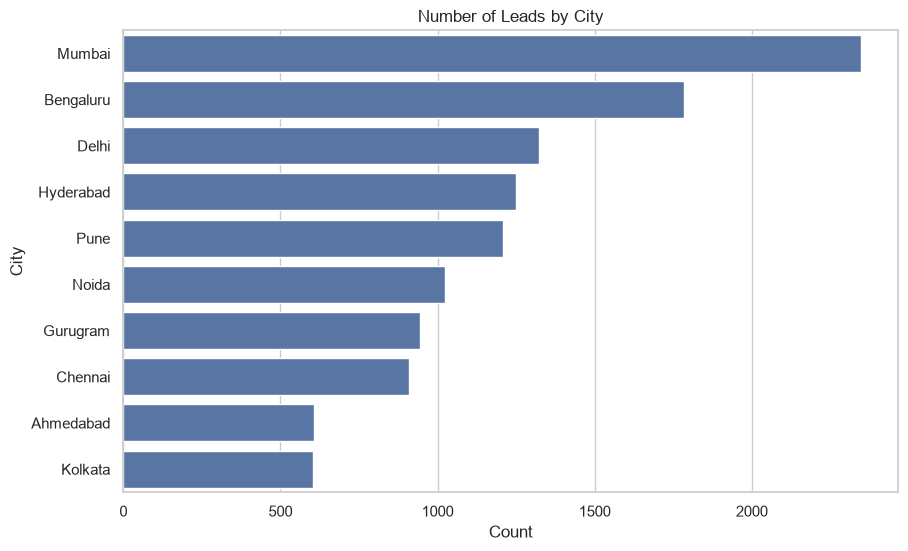

In [7]:
city_counts = users['City'].value_counts()
"""print(city_counts)"""

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Number of Leads by City')
plt.xlabel('Count')
plt.savefig('../reports/figures/citywise_leadcount.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.4 Plot budget & preferred plot size

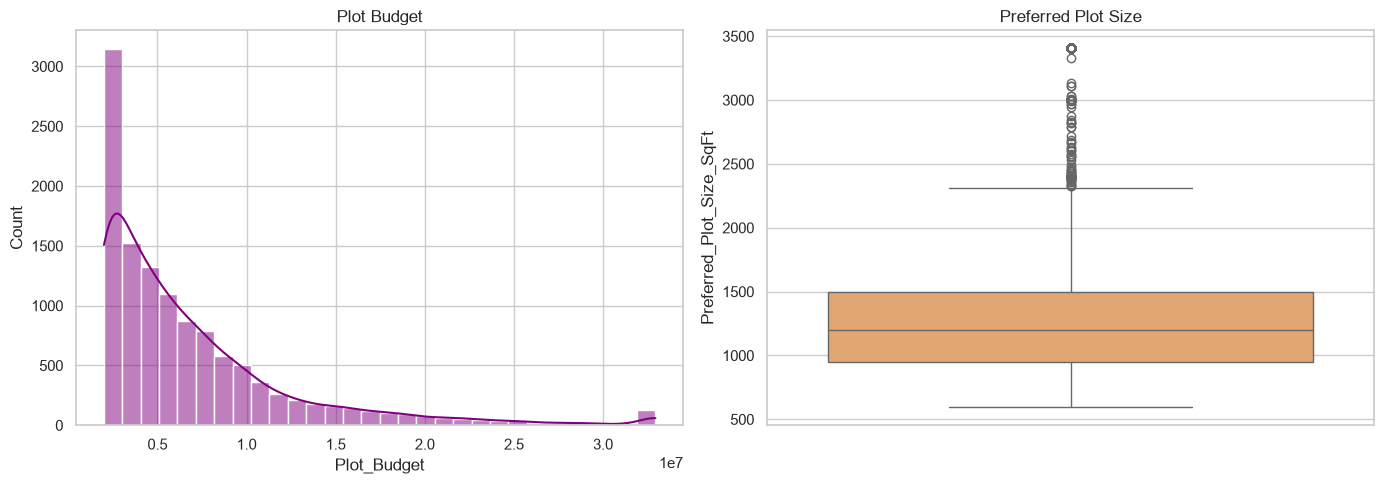

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Plot_Budget'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Plot Budget')

sns.boxplot(y=users['Preferred_Plot_Size_SqFt'], ax=axes[1], color='sandybrown')
axes[1].set_title('Preferred Plot Size')

plt.savefig('../reports/figures/plot_budget_&_plot_size.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 2.5 Loan requirement , Purpose & Purchase intent

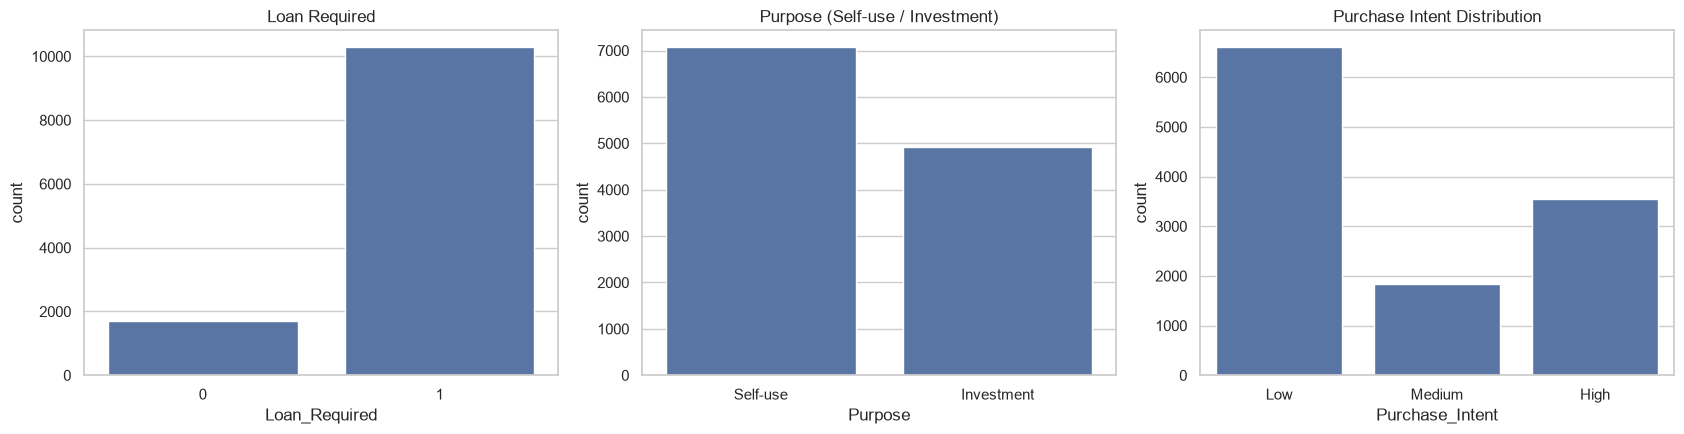

In [9]:
intent_counts = users['Purchase_Intent'].value_counts().reindex(['Low', 'Medium', 'High'])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Loan_Required', ax=axes[0])
axes[0].set_title('Loan Required')

sns.countplot(data=users, x='Purpose', ax=axes[1])
axes[1].set_title('Purpose (Self-use / Investment)')

sns.barplot(x=intent_counts.index ,y=intent_counts.values, ax=axes[2])
axes[2].set_title('Purchase Intent Distribution')
plt.ylabel('count')

plt.savefig('../reports/figures/Loan_requirement-Purpose-Purchase_intent.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 2.6 Behavioral funnel vs Purchased (barplot)

For each behavioral step (previous enquiry, site visit, negotiation, booking), we check
what percentage of people who did "Yes" on that step actually purchased. Since
`Purchased` is already 0/1, `groupby().mean()` directly gives us that percentage.


In [10]:
funnel_cols = ['Previous_Enquiry', 'Site_Visit', 'Negotiation_Done', 'Booking_Done']

for col in funnel_cols:
    conversion = users.groupby(col)['Purchased'].mean() * 100
    print(f"--- {col} ---")
    print(conversion.round(1))
    print()


--- Previous_Enquiry ---
Previous_Enquiry
0    37.5
1    46.1
Name: Purchased, dtype: float64

--- Site_Visit ---
Site_Visit
0    16.4
1    54.9
Name: Purchased, dtype: float64

--- Negotiation_Done ---
Negotiation_Done
0    25.9
1    87.6
Name: Purchased, dtype: float64

--- Booking_Done ---
Booking_Done
0     0.0
1    98.1
Name: Purchased, dtype: float64



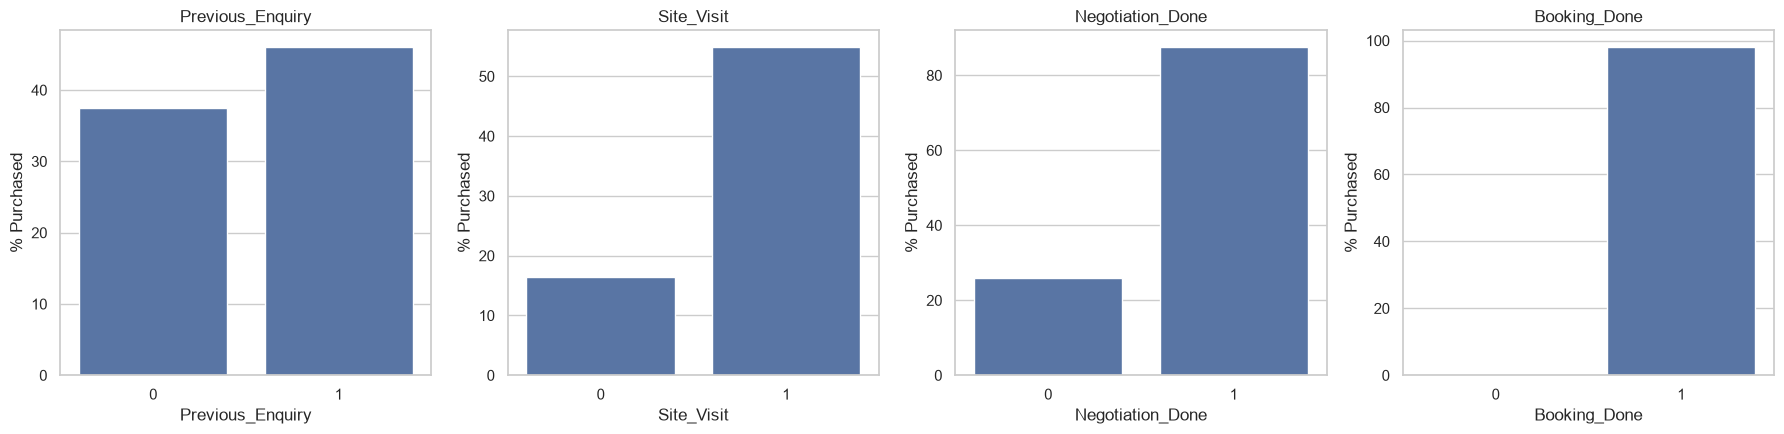

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, col in zip(axes, funnel_cols):
    conversion = users.groupby(col)['Purchased'].mean() * 100
    sns.barplot(x=conversion.index, y=conversion.values, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('% Purchased')

plt.tight_layout()
plt.show()


## 2.7 Income vs Plot Budget relationship (scatterplot)

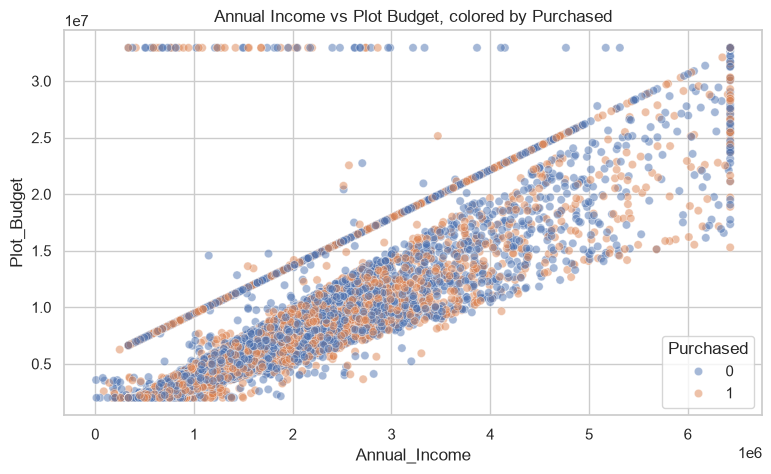

In [12]:
plt.figure()
sns.scatterplot(data=users, x='Annual_Income', y='Plot_Budget', hue='Purchased', alpha=0.5)
plt.title('Annual Income vs Plot Budget, colored by Purchased')
plt.savefig('../reports/figures/income-vs-plot_budget.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.8 Occupation vs conversion (barplot)

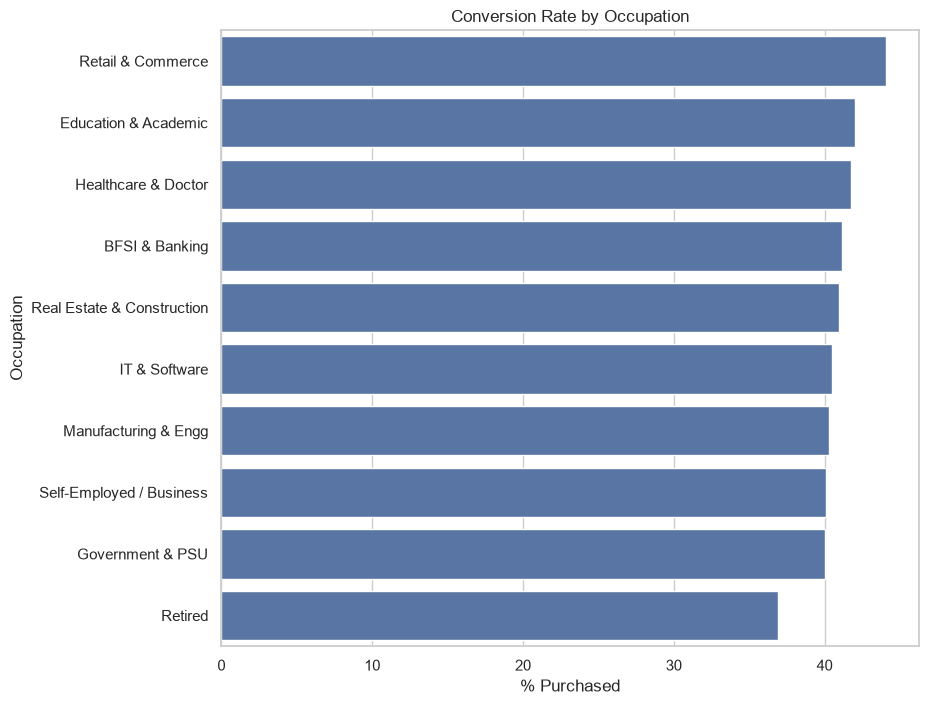

In [13]:
occupation_conversion = users.groupby('Occupation')['Purchased'].mean().sort_values(ascending=False) * 100
"""print(occupation_conversion.round(1))"""

plt.figure(figsize=(9, 8))
sns.barplot(x=occupation_conversion.values, y=occupation_conversion.index)
plt.title('Conversion Rate by Occupation')
plt.xlabel('% Purchased')
plt.savefig('../reports/figures/occupation-vs-conversion.png', dpi=300, bbox_inches='tight')
plt.show()


## 2.9 Correlation heatmap (numeric features)

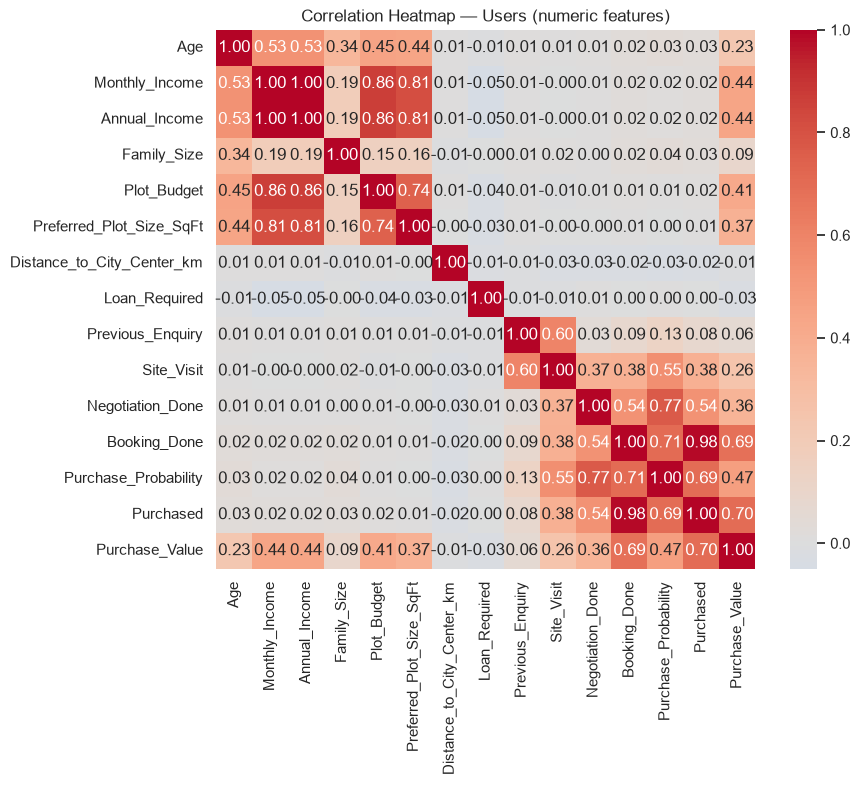

In [14]:
numeric_cols = users.select_dtypes(include='number').columns
corr = users[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Users (numeric features)')
plt.savefig('../reports/figures/heatmap(users).png', dpi=300, bbox_inches='tight')
plt.show()


---
## Key Takeaways

1. **Class balance (`Purchased`)**
   > **59.25% did not purchase, 40.75% did purchase.** Not extremely imbalanced, but worth
   > keeping in mind for modelling.

2. **Behavioral funnel is the strongest signal**
   > Conversion rate rises sharply at each step: **37.5% → 46.1%** with a previous enquiry,
   > **16.4% → 54.9%** with a site visit, **25.9% → 87.6%** after negotiation, and
   > **0.0% → 98.1%** after a booking is done. `Booking_Done` and `Site_Visit` are by far
   > the strongest predictors of `Purchased` in this dataset.

3. **Financial fields matter far less than behavior**
   > Median `Plot_Budget` is ₹50.15L for non-buyers vs ₹52.2L for buyers, and median
   > `Annual_Income` is ₹12.89L vs ₹13.30L — both differences are small (under 4%).
   > Behavior (funnel steps) separates buyers from non-buyers far more than income or
   > budget does.

4. **Lead source and Occupation both show narrow, weak spreads**
   > Lead source conversion ranges only **39.3%–41.2%** across all 5 sources, and
   > Occupation ranges only **36.9%–44.1%** across all 10 categories. Neither field
   > meaningfully separates buyers from non-buyers on its own — both are much flatter than
   > the funnel columns above.

**Takeaway for modelling:** behavioral columns (`Booking_Done`, `Site_Visit`,
`Negotiation_Done`) are far more predictive of `Purchased` than demographic, financial,
occupation, or lead-source columns — those latter fields add little on their own.

**File:** `historical_scheme_data.csv`

This notebook looks at historical housing/plot schemes (projects) — pricing, amenities,
advertising spend, and how successful each scheme was.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)

In [2]:
schemes = pd.read_csv('../data/processed/historical_scheme_data.csv')
print("Shape:", schemes.shape)
schemes.head()

Shape: (800, 16)


,Scheme_ID,Location,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Park,Clubhouse,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Demand_Level,Scheme_Success_Score,Target_Age_Group,Most_Likely_Buyers
0,SCH_0101,Delhi (Outer/Bawana),800,1320000,9200,Yes,No,3.9,1500000,3230,602,18.6,HIGH,79,25-38,First-time Buyers & Investors
1,SCH_0102,Gurugram (SPR/Sohna),1800,8270000,57400,Yes,Yes,16.2,1500000,2335,348,14.9,HIGH,79,40-60,Affluent Investors & Luxury Homes
2,SCH_0103,Kolkata (New Town/Rajarhat),1500,3030000,21000,Yes,No,5.5,750000,1267,227,17.9,MEDIUM,74,25-38,First-time Buyers & Investors
3,SCH_0104,Bengaluru (North),1000,6360000,44200,Yes,No,23.9,1000000,1015,99,9.8,LOW,41,32-48,Self-use (Villa) + Investment
4,SCH_0105,Greater Noida,2400,8150000,56600,No,No,23.4,1000000,1180,73,6.2,LOW,25,40-60,Affluent Investors & Luxury Homes


## 3.0 Price, Plot size & Monthly EMI distribution

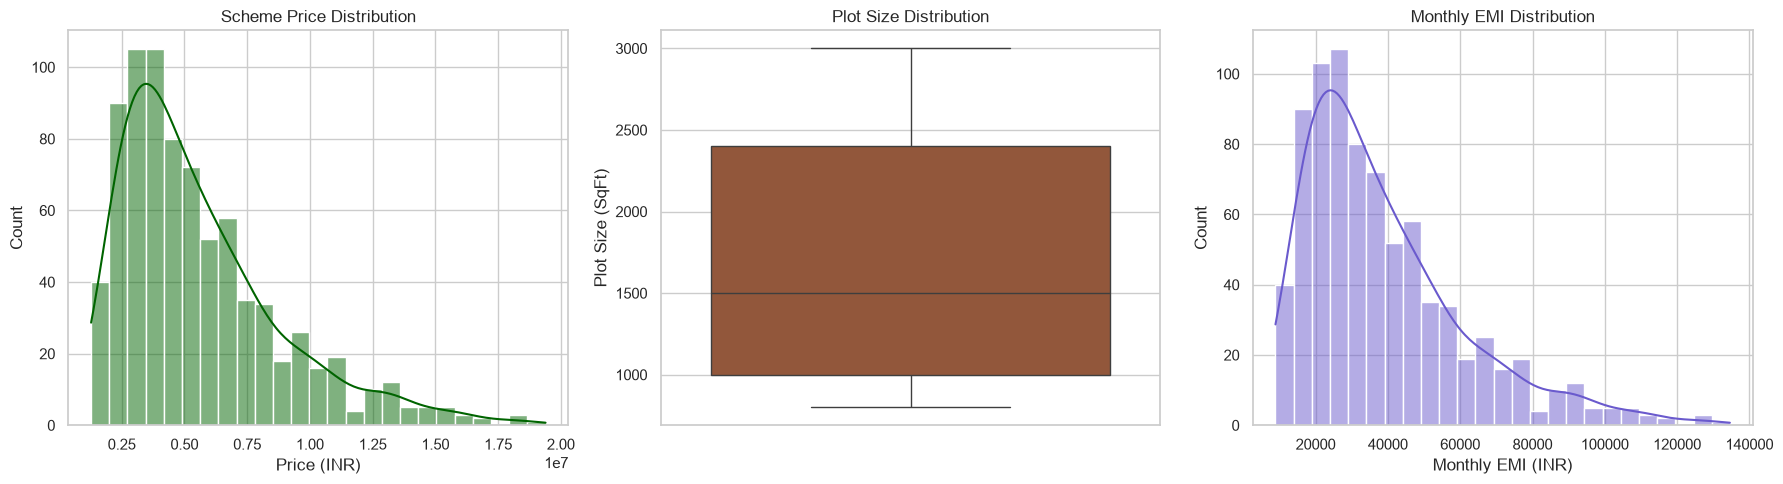

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Price Distribution
sns.histplot(schemes['Price_INR'], bins=25, kde=True, color='darkgreen', ax=axes[0])
axes[0].set_title('Scheme Price Distribution')
axes[0].set_xlabel('Price (INR)')

# Plot 2: Plot Size Distribution
sns.boxplot(y=schemes['Plot_Size_SqFt'], color='sienna', ax=axes[1])
axes[1].set_title('Plot Size Distribution')
axes[1].set_ylabel('Plot Size (SqFt)')

# Plot 3: Monthly EMI Distribution
sns.histplot(schemes['Monthly_EMI_INR'], bins=25, kde=True, color='slateblue', ax=axes[2])
axes[2].set_title('Monthly EMI Distribution')
axes[2].set_xlabel('Monthly EMI (INR)')

plt.savefig('../reports/figures/price-plot_size-monthly_emi.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 3.1 Price by Location 

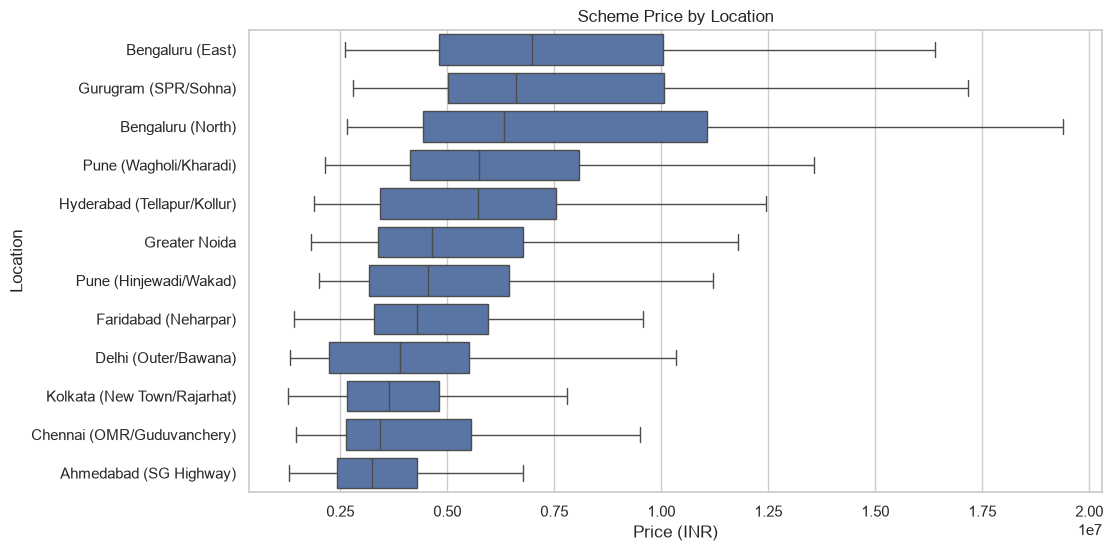

In [4]:
plt.figure(figsize=(11, 6))
order_loc = schemes.groupby('Location')['Price_INR'].median().sort_values(ascending=False).index
sns.boxplot(data=schemes, x='Price_INR', y='Location', order=order_loc, showfliers=False)
plt.title('Scheme Price by Location')
plt.xlabel('Price (INR)')
plt.savefig('../reports/figures/price_by_location.png', dpi=300, bbox_inches='tight')
plt.show()


## 3.2 Plot size vs Price relationship

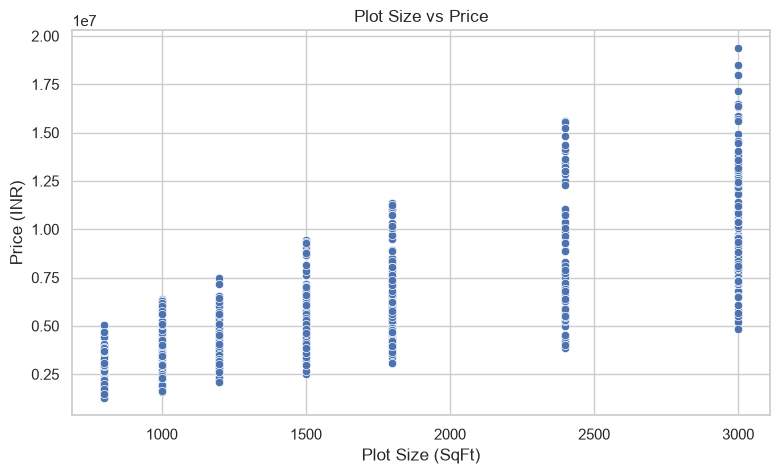

In [5]:
plt.figure()
sns.scatterplot(data=schemes, x='Plot_Size_SqFt', y='Price_INR')
plt.title('Plot Size vs Price')
plt.xlabel('Plot Size (SqFt)')
plt.ylabel('Price (INR)')
plt.savefig('../reports/figures/plot_size-vs-price.png', dpi=300, bbox_inches='tight')
plt.show()


## 3.3 Distance from Metro 

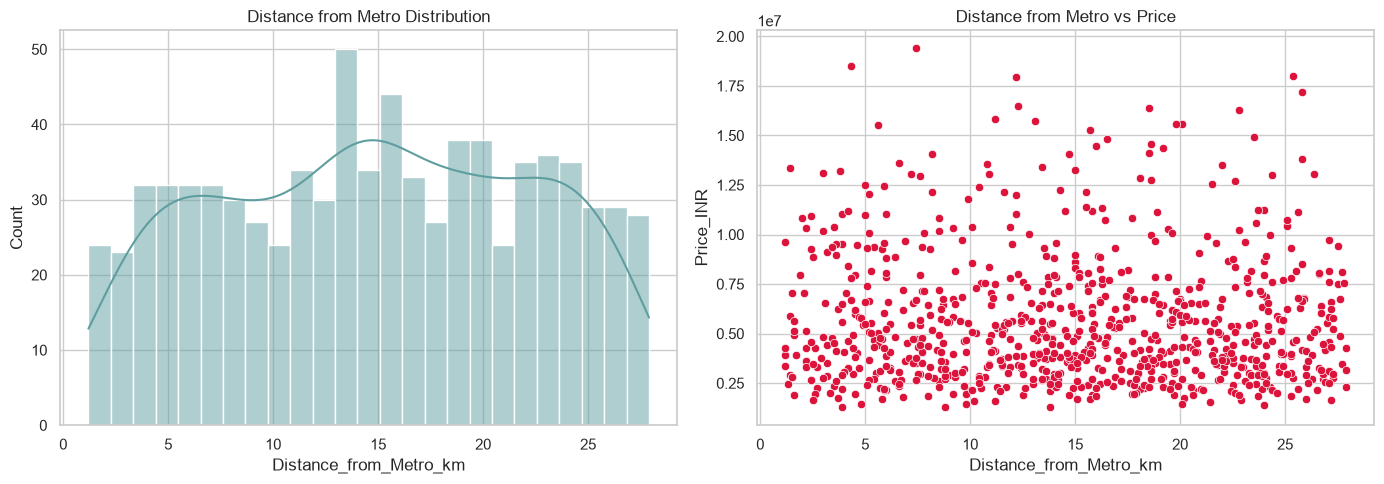

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(schemes['Distance_from_Metro_km'], bins=25, kde=True, ax=axes[0], color='cadetblue')
axes[0].set_title('Distance from Metro Distribution')

sns.scatterplot(data=schemes, x='Distance_from_Metro_km', y='Price_INR', ax=axes[1], color='crimson')
axes[1].set_title('Distance from Metro vs Price')

plt.savefig('../reports/figures/distance_from_metro.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.4 Demand level & Success score 

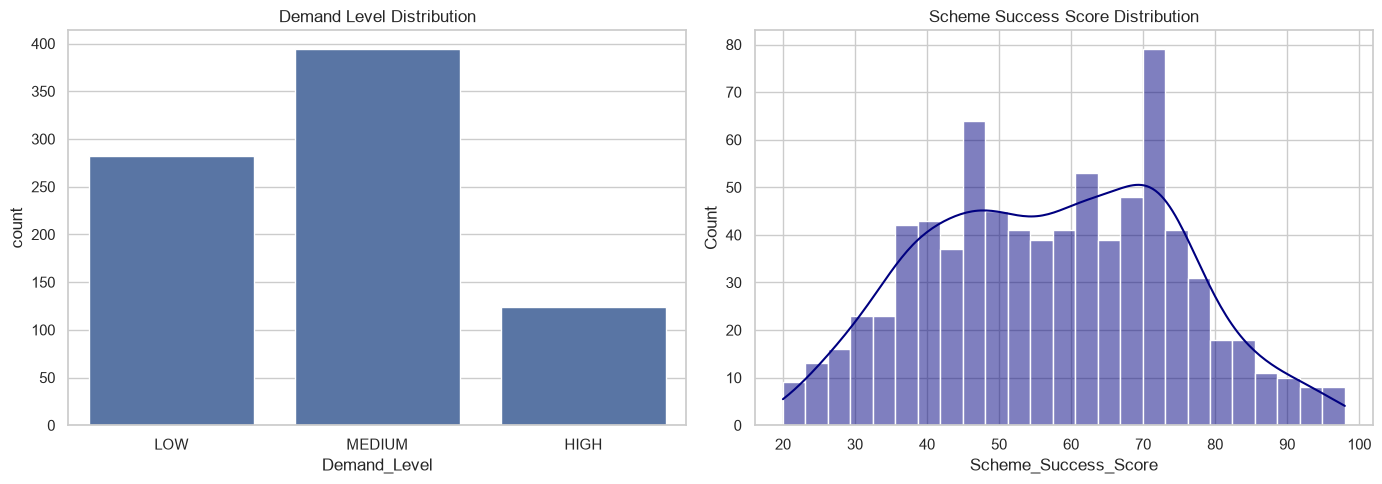

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=schemes, x='Demand_Level', order=['LOW', 'MEDIUM', 'HIGH'], ax=axes[0])
axes[0].set_title('Demand Level Distribution')

sns.histplot(schemes['Scheme_Success_Score'], bins=25, kde=True, ax=axes[1], color='navy')
axes[1].set_title('Scheme Success Score Distribution')

plt.savefig('../reports/figures/demand_level-success_score.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.5 Advertising budget vs Leads and Bookings

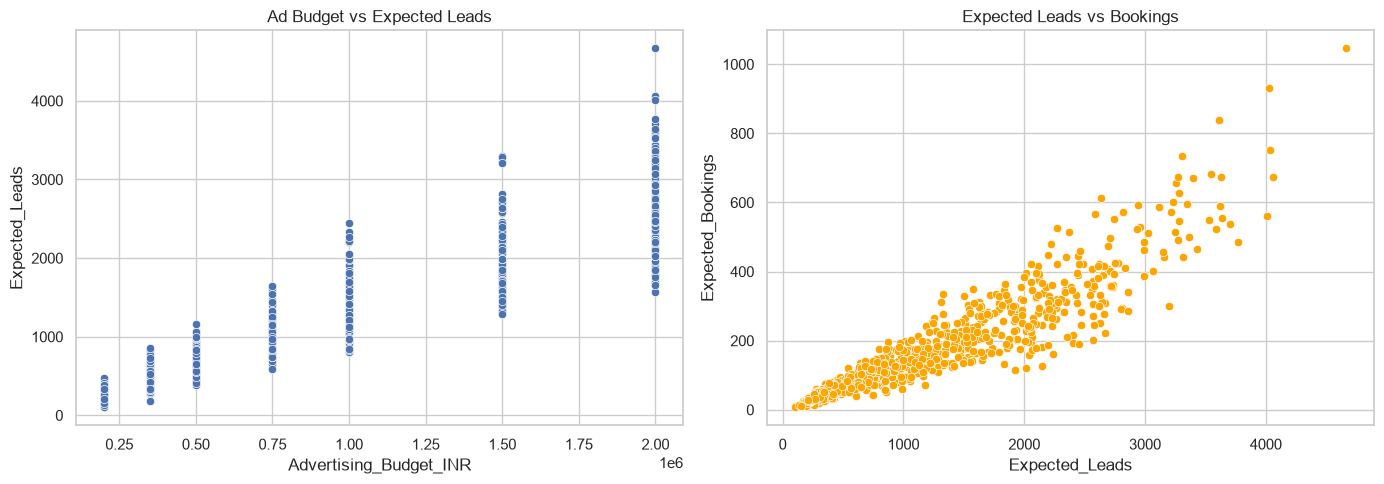

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=schemes, x='Advertising_Budget_INR', y='Expected_Leads', ax=axes[0])
axes[0].set_title('Ad Budget vs Expected Leads')

sns.scatterplot(data=schemes, x='Expected_Leads', y='Expected_Bookings', ax=axes[1], color='orange')
axes[1].set_title('Expected Leads vs Bookings')

plt.savefig('../reports/figures/budget-vs-leads-&-booking.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.6 Amenities : Park & Clubhouse

We group schemes by whether they have a Park/Clubhouse (Yes/No) and check the average
success score for each group, using plain `groupby().mean()`.


In [9]:
park_success = schemes.groupby('Park')['Scheme_Success_Score'].mean()
clubhouse_success = schemes.groupby('Clubhouse')['Scheme_Success_Score'].mean()

print("Average success score by Park:")
print(park_success.round(1))
print()
print("Average success score by Clubhouse:")
print(clubhouse_success.round(1))


Average success score by Park:
Park
No     55.2
Yes    61.0
Name: Scheme_Success_Score, dtype: float64

Average success score by Clubhouse:
Clubhouse
No     53.2
Yes    72.0
Name: Scheme_Success_Score, dtype: float64


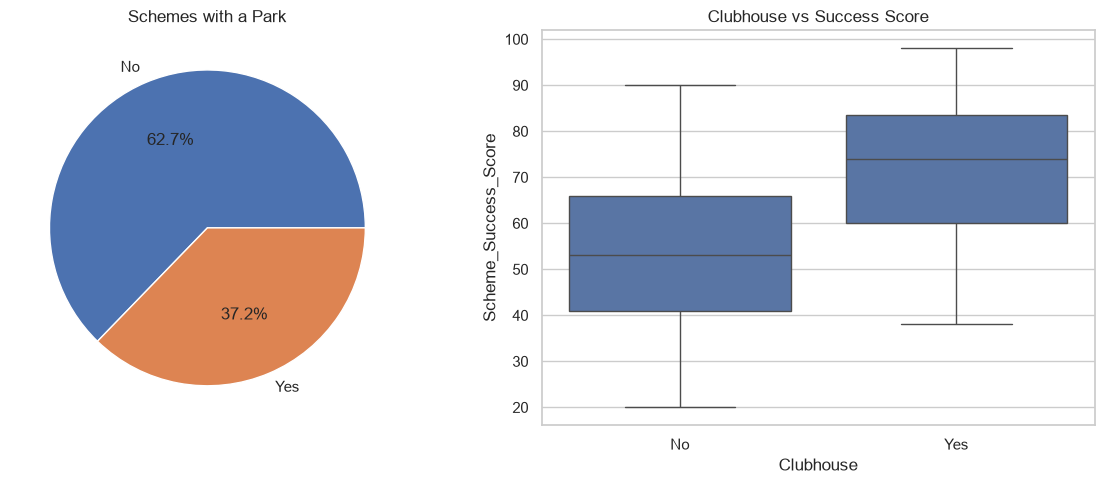

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

park_counts = schemes['Park'].value_counts()
axes[0].pie(park_counts, labels=park_counts.index, autopct='%1.1f%%')
axes[0].set_title('Schemes with a Park')

sns.boxplot(data=schemes, x='Clubhouse', y='Scheme_Success_Score', ax=axes[1])
axes[1].set_title('Clubhouse vs Success Score')

plt.savefig('../reports/figures/amenities-park-&-clubhouse.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.7 Target age group & most likely buyer segments

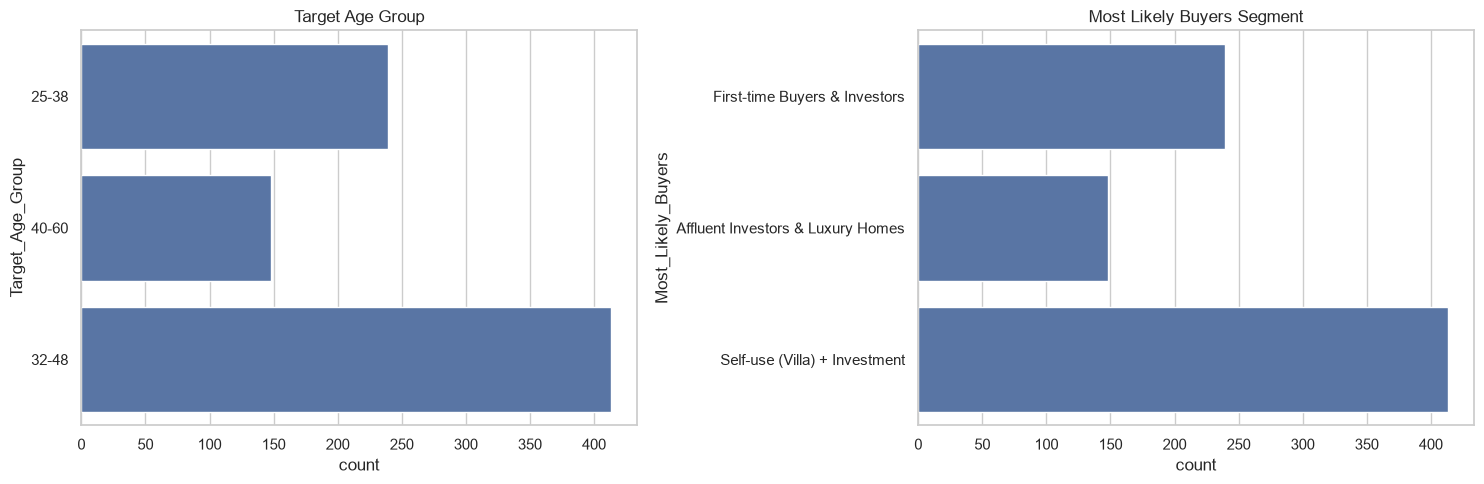

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=schemes, y='Target_Age_Group', ax=axes[0])
axes[0].set_title('Target Age Group')

sns.countplot(data=schemes, y='Most_Likely_Buyers', ax=axes[1])
axes[1].set_title('Most Likely Buyers Segment')

plt.savefig('../reports/figures/target_age-&-buyers.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 3.8 Success score by location

Location
Faridabad (Neharpar)           61.0
Greater Noida                  61.0
Delhi (Outer/Bawana)           61.0
Ahmedabad (SG Highway)         60.0
Pune (Wagholi/Kharadi)         59.5
Pune (Hinjewadi/Wakad)         59.0
Hyderabad (Tellapur/Kollur)    58.0
Kolkata (New Town/Rajarhat)    58.0
Gurugram (SPR/Sohna)           57.0
Chennai (OMR/Guduvanchery)     56.5
Bengaluru (North)              52.0
Bengaluru (East)               50.0
Name: Scheme_Success_Score, dtype: float64


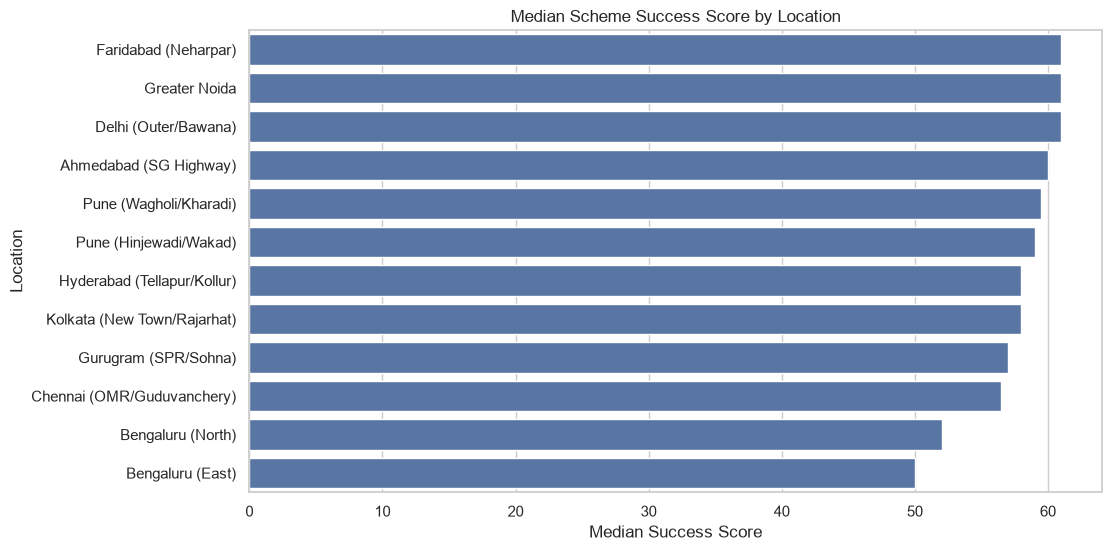

In [12]:
location_success = schemes.groupby('Location')['Scheme_Success_Score'].median().sort_values(ascending=False)
print(location_success.round(1))

plt.figure(figsize=(11, 6))
sns.barplot(x=location_success.values, y=location_success.index)
plt.title('Median Scheme Success Score by Location')
plt.xlabel('Median Success Score')
plt.savefig('../reports/figures/Success_score(location).png', dpi=300, bbox_inches='tight')
plt.show()


## 3.9 Correlation heatmap (numeric features)

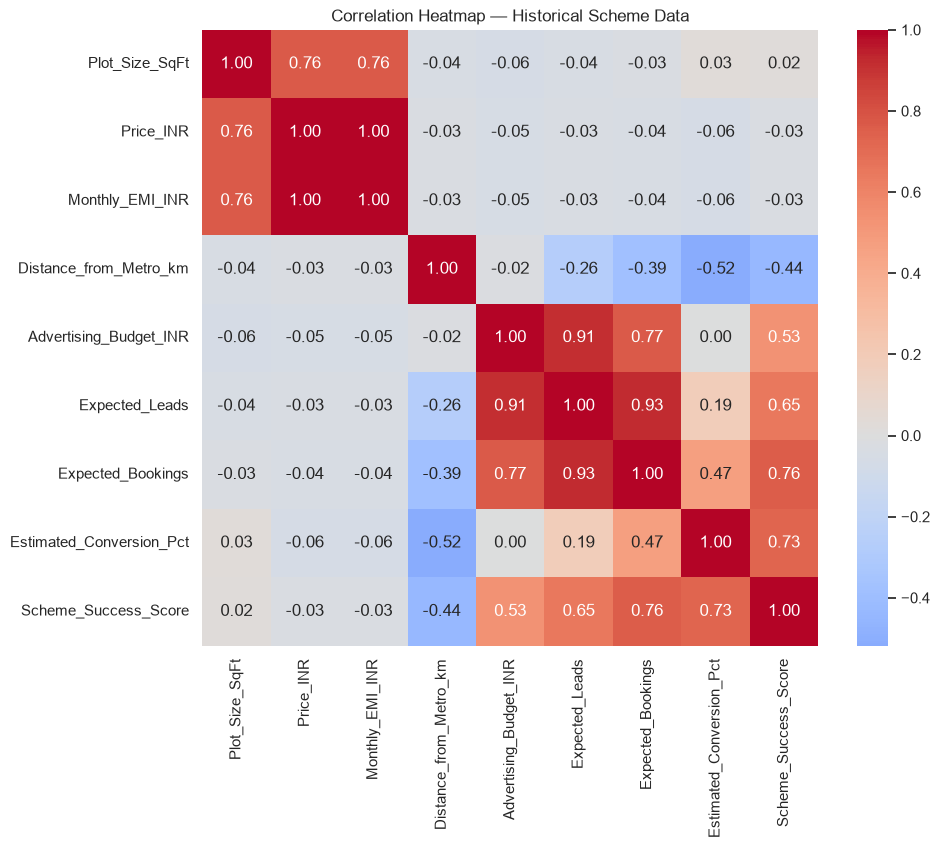

In [13]:
numeric_cols = schemes.select_dtypes(include='number').columns
corr = schemes[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Historical Scheme Data')
plt.savefig('../reports/figures/heatmap(scheme).png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
corr['Scheme_Success_Score'].sort_values(ascending=False)

Scheme_Success_Score        1.000000
Expected_Bookings           0.761300
Estimated_Conversion_Pct    0.730691
Expected_Leads              0.653219
Advertising_Budget_INR      0.532892
Plot_Size_SqFt              0.019392
Price_INR                  -0.028604
Monthly_EMI_INR            -0.028633
Distance_from_Metro_km     -0.437009
Name: Scheme_Success_Score, dtype: float64

---
## Key Takeaways

1. **What drives `Scheme_Success_Score`**
   > The score correlates strongly with `Expected_Bookings` (0.76), `Estimated_Conversion_Pct`
   > (0.73), `Expected_Leads` (0.65), and `Advertising_Budget_INR` (0.53). It correlates
   > negatively with `Distance_from_Metro_km` (-0.44). But `Price_INR` and `Plot_Size_SqFt`
   > are close to 0 — price and size barely relate to success.

2. **Demand level lines up with success score**
   > Average success score is highest for **HIGH demand** schemes (82.75), middle for
   > **MEDIUM** (62.79), and lowest for **LOW** (38.59) — a clear, expected pattern.

3. **Clubhouse matters more than Park — and most schemes don't have either**
   > Schemes with a Clubhouse average a 72.0 success score vs 53.2 without (a ~19-point gap).
   > Park makes a smaller difference (61.0 vs 55.2, a ~6-point gap). Note: most schemes in
   > the dataset do **not** have a Park (62.75% have none) or a Clubhouse (78.1% have none).

4. **Being far from a metro station hurts conversion — but not price**
   > `Distance_from_Metro_km` has a fairly strong negative correlation with
   > `Estimated_Conversion_Pct` (-0.52) — schemes farther from a metro convert leads into
   > bookings less often. It has almost no relationship with `Price_INR` (-0.03).

5. **Advertising spend brings leads, but has no effect on conversion rate**
   > `Advertising_Budget_INR` correlates strongly with `Expected_Leads` (0.91), but is
   > essentially uncorrelated with `Estimated_Conversion_Pct` (0.002) — more ad spend brings
   > more leads in absolute terms, but doesn't make each lead more likely to convert.

6. **Higher price doesn't mean higher success**
   > Bengaluru (East) has the highest median price (₹69.85L) but one of the lowest median
   > success scores (50). Ahmedabad (SG Highway) has the lowest median price (₹32.45L) but
   > one of the highest success scores (60). Price alone isn't a good predictor of success.

**Takeaway for modelling:** funnel-related numbers (leads, bookings, conversion %) and
location/amenities explain most of the variation in success score — price and plot size
don't. If you plan to predict `Scheme_Success_Score`, be careful that
`Expected_Bookings`/`Estimated_Conversion_Pct` aren't already "giving away" the answer.